## Encoding Numerical Features in Machine Learning

Machine learning algorithms work only with numbers, but not all numerical features are in a good form for learning. Some numerical data (like app download counts) can be very **skewed**, making it hard for models to learn patterns. In such cases, we can **encode numerical features** by turning them into categorical ones using **discretization (binning)**, or into binary values using **binarization**.[^1][^2]

***

## Discretization (Binning)

Discretization (also called **binning**) is the process of transforming continuous variables into categorical variables by splitting the value range into a set of contiguous intervals (bins).[^3][^1]

### Benefits of discretization

- Handles outliers better by grouping extreme values into bins.[^4]
- Improves the spread of values, especially when the data is skewed.[^1]
- Minimizes the effect of small observation or measurement errors.[^4]

***

## Types of Binning

### 1. Unsupervised Binning

#### a) Equal width binning (Uniform binning)

- The range of the data is divided into $N$ intervals of equal width.[^2][^5]
- Width of each interval:

$$
w = \frac{\text{max} - \text{min}}{N}
$$
- Interval boundaries:

$$
\text{min} + w,\ \text{min} + 2w,\ \dots,\ \text{min} + (N-1)w
$$
- Does not change the data distribution shape but groups outliers into bins.[^6][^5]


#### b) Equal frequency binning (Quantile binning)

- The data is sorted and split into $N$ bins so that each bin has approximately the same number of observations.[^2][^6]
- Bin widths (in terms of value range) are not necessarily equal.[^2]
- Handles outliers better than equal width and makes bin counts roughly uniform.[^7][^2]


#### c) K-means binning

- Uses the **K-means clustering** algorithm on the numerical values.[^4][^1]
- Let $X = \{x_1, x_2, \dots, x_n\}$ be observations and $V = \{v_1, v_2, \dots, v_c\}$ be centroids, where $c$ = number of bins.[^4]
- Algorithm steps:[^4]

1. Randomly select $c$ centroids.
2. Compute distance from each observation to each centroid.
3. Assign each observation to the nearest centroid.
4. Recompute centroids as the mean of points in each cluster.
5. Repeat steps 2–4 until assignments stop changing.


### 2. Custom (Domain-based) Binning

- Bins are defined using domain knowledge and business rules.[^8]
- Example: **Age** values
    - 10, 11, 13, 14, 17, 19 → **Young**
    - 30, 31, 32, 38, 40, 42 → **Mature**
    - 70, 72, 73, 75 → **Old**
- Implementation is typically done manually (e.g., using conditional logic in pandas).[^8]

***

## Binarization

Binarization is a special case of binning where continuous values are converted into **binary values (0 or 1)** based on a chosen threshold.[^9][^10]

### Example: Income

- If annual income < 5 lakhs → 0 (non-taxable).
- If annual income ≥ 5 lakhs → 1 (taxable).


### Example: Image processing

- Pixel values range from 0 to 255.[^9]
- Choose a threshold $T$:
    - Pixel value < $T$ → 0 (black).
    - Pixel value ≥ $T$ → 1 (white).
- This converts a colored (or grayscale) image into a black-and-white (binary) image.[^9]


### Implementation (Scikit-learn)

- Use `sklearn.preprocessing.Binarizer`.[^10]
- Important parameters:[^10]
    - `threshold`: values greater than this become 1; less than or equal become 0.
    - `copy`:
        - `True` → create a new transformed output.
        - `False` → modify data in place.

***

## Quick Comparison

| Technique | What it does | When to use |
| :-- | :-- | :-- |
| Equal width binning | Splits range into equal-width intervals | Simple binning, basic outlier handling |
| Equal frequency binning | Makes bins with similar counts of observations | Balancing data across bins, handling skewed data |
| K-means binning | Forms bins via clustering around centroids | When data naturally forms clusters |
| Custom binning | Uses business/domain rules for ranges | When interpretability and domain meaning are important |
| Binarization | Converts values to 0/1 using a threshold | Binary decisions, classification, image thresholding |



<div align="center">⁂</div>

[^1]: https://mlpills.substack.com/p/issue-93-binning-in-machine-learning

[^2]: https://k-dm.work/en/prep/numerical/binning/

[^3]: https://www.geeksforgeeks.org/machine-learning/ml-binning-or-discretization/

[^4]: https://medium.com/@noorfatimaafzalbutt/discretization-binning-in-machine-learning-da3ad71ceb36

[^5]: https://www.naukri.com/code360/library/binning-in-data-mining

[^6]: https://www.adventuresinmachinelearning.com/binning-techniques-dividing-data-for-optimal-visualization-and-analysis/

[^7]: https://www.scribd.com/document/987498474/EDA-3

[^8]: https://medium.com/@adnan.mazraeh1993/comprehensive-guide-to-binning-discretization-in-data-science-from-basics-to-super-advanced-006c2e215a9f

[^9]: https://www.youtube.com/watch?v=vG76WwdPRVo

[^10]: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.Binarizer.html



In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('train.csv', usecols=['Age','Fare','Survived'])
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [3]:
df.shape

(891, 3)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Age       714 non-null    float64
 2   Fare      891 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 21.0 KB


In [5]:
df.dropna(inplace= True)

In [6]:
df.shape

(714, 3)

In [7]:
from sklearn.model_selection import train_test_split

X = df.drop(columns='Survived')
y = df['Survived']


X_train,X_test, y_train,y_test = train_test_split(X,y,test_size = 0.2, random_state = 43)

In [9]:
print('X_train shape',X_train.shape)
print('X_test shape',X_test.shape)
print('y_train shape',y_train.shape)
print('y_test shape',y_test.shape)

X_train shape (571, 2)
X_test shape (143, 2)
y_train shape (571,)
y_test shape (143,)


In [11]:
X_train.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,571.0,29.389965,14.555649,0.42,20.00,28.0,38.0000,80.0000
Fare,571.0,34.277634,51.647691,0.00,8.05,15.0,33.7604,512.3292


### Without Discretization

In [12]:
from sklearn.tree import DecisionTreeClassifier


clf = DecisionTreeClassifier()

clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)

In [13]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test,y_pred)

0.6433566433566433

In [14]:
from sklearn.model_selection import cross_val_score

np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))

np.float64(0.6344679186228481)

### With Discretizataion

In [15]:
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer



kbin_age = KBinsDiscretizer(n_bins=10,encode='ordinal',strategy='quantile')
kbin_fare = KBinsDiscretizer(n_bins=10,encode='ordinal',strategy='quantile')

transformer = ColumnTransformer([
    ('encoded_age',kbin_age,['Age']),
    ('encoded_fare',kbin_fare,['Fare'])
])

In [16]:
transformer.set_output(transform='pandas')

X_train_transformed = transformer.fit_transform(X_train)
X_test_transformed = transformer.transform(X_test)


print(X_train_transformed.shape)
print(X_test_transformed.shape)

(571, 2)
(143, 2)


In [17]:
X_train_transformed.head()

,encoded_age__Age,encoded_fare__Fare
83,5.0,8.0
646,2.0,2.0
635,5.0,4.0
827,0.0,7.0
685,4.0,7.0


In [18]:
X_test_transformed.head()

,encoded_age__Age,encoded_fare__Fare
333,1.0,5.0
777,0.0,3.0
715,2.0,0.0
604,7.0,6.0
730,5.0,9.0


In [19]:
transformer.named_transformers_.encoded_age.bin_edges_

array([array([ 0.42, 13.  , 18.  , 22.  , 24.  , 28.  , 31.  , 35.  , 40.5 ,
              50.  , 80.  ])                                                ],
      dtype=object)

In [20]:
transformer.named_transformers_.encoded_fare.bin_edges_

array([array([  0.    ,   7.7417,   7.8958,   9.225 ,  12.525 ,  15.    ,
               24.15  ,  29.    ,  46.9   ,  79.2   , 512.3292])         ],
      dtype=object)

In [21]:
output = pd.DataFrame({
    'age':X_train['Age'],
    'encoded_age':X_train_transformed['encoded_age__Age'],
    'fare':X_train['Fare'],
    'encoded_fare':X_train_transformed['encoded_fare__Fare']
})

output.head()

,age,encoded_age,fare,encoded_fare
83,28.0,5.0,47.1000,8.0
646,19.0,2.0,7.8958,2.0
635,28.0,5.0,13.0000,4.0
827,1.0,0.0,37.0042,7.0
685,25.0,4.0,41.5792,7.0


In [22]:
output['age_labels'] = pd.cut(x=X_train['Age'], bins = transformer.named_transformers_.encoded_age.bin_edges_[0])
output['fare_labels'] = pd.cut(x=X_train['Fare'], bins = transformer.named_transformers_.encoded_fare.bin_edges_[0])

In [23]:
output.sample(6)

,age,encoded_age,fare,encoded_fare,age_labels,fare_labels
215,31.0,6.0,113.2750,9.0,"(28.0, 31.0]","(79.2, 512.329]"
208,16.0,1.0,7.7500,1.0,"(13.0, 18.0]","(7.742, 7.896]"
137,37.0,7.0,53.1000,8.0,"(35.0, 40.5]","(46.9, 79.2]"
579,32.0,6.0,7.9250,2.0,"(31.0, 35.0]","(7.896, 9.225]"
731,11.0,0.0,18.7875,5.0,"(0.42, 13.0]","(15.0, 24.15]"
873,47.0,8.0,9.0000,2.0,"(40.5, 50.0]","(7.896, 9.225]"


In [24]:
clf_v2 = DecisionTreeClassifier()

clf_v2.fit(X_train_transformed, y_train)
y_pred_v2 = clf_v2.predict(X_test_transformed)

In [25]:
accuracy_score(y_test, y_pred_v2)

0.7202797202797203

In [26]:
X_transformed = transformer.fit_transform(X)
np.mean(cross_val_score(DecisionTreeClassifier(),X_transformed,y,cv=16,scoring='accuracy'))

np.float64(0.6919191919191919)

In [27]:
X_transformed

,encoded_age__Age,encoded_fare__Fare
0,3.0,0.0
1,7.0,8.0
2,4.0,2.0
3,6.0,8.0
4,6.0,2.0
...,...,...
885,7.0,7.0
886,4.0,4.0
887,2.0,7.0
889,4.0,7.0


In [28]:
import matplotlib.pyplot as plt

def discretize(bins,strategy):
    kbin_age = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    kbin_fare = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    
    transformer = ColumnTransformer([
        ('encoded_age',kbin_age,['Age']),
        ('encoded_fare',kbin_fare,['Fare'])
    ])

    transformer.set_output(transform='pandas')
    
    X_transformed = transformer.fit_transform(X)
    print(np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy')))
    
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Age'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_transformed['encoded_age__Age'],color='red')
    plt.title("After")

    plt.show()
    
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Fare'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_transformed['encoded_fare__Fare'],color='red')
    plt.title("Fare")

    plt.show()

0.6373239436619718


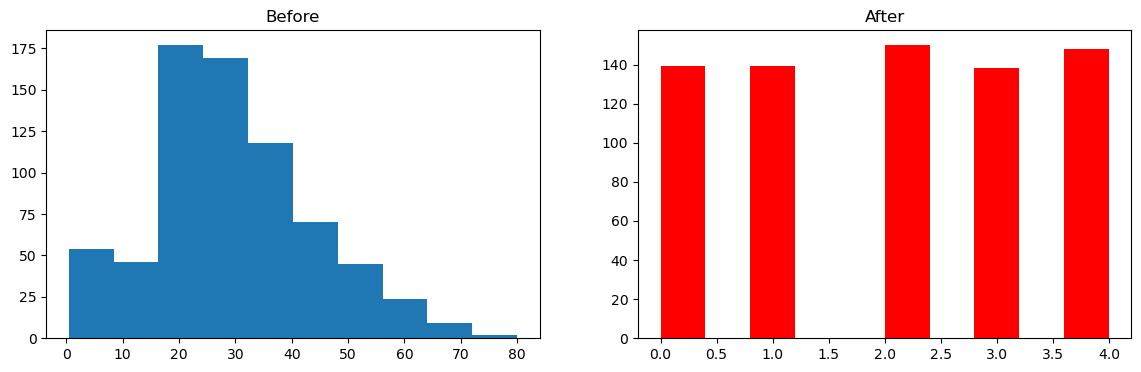

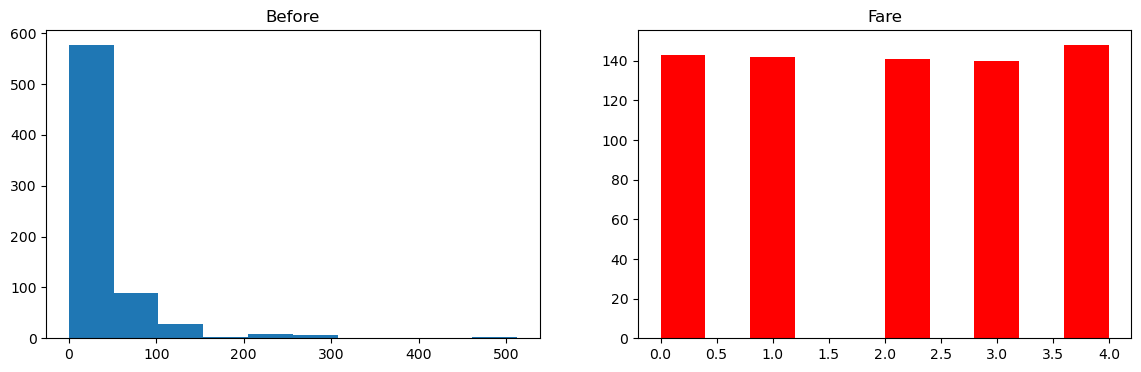

In [29]:
discretize(5,'quantile')

### Binarization

In [30]:
df = pd.read_csv('train.csv')[['Age','Fare','SibSp','Parch','Survived']]
df.head()

,Age,Fare,SibSp,Parch,Survived
0,22.0,7.2500,1,0,0
1,38.0,71.2833,1,0,1
2,26.0,7.9250,0,0,1
3,35.0,53.1000,1,0,1
4,35.0,8.0500,0,0,0


In [33]:
df.isnull().sum()

Age         177
Fare          0
SibSp         0
Parch         0
Survived      0
dtype: int64

In [34]:
df.dropna(inplace=True)

In [35]:
df.isnull().sum()

Age         0
Fare        0
SibSp       0
Parch       0
Survived    0
dtype: int64

In [36]:
df['Family'] = df['SibSp'] + df['Parch']

In [39]:
df.Family

0      1
1      1
2      0
3      1
4      0
      ..
885    5
886    0
887    0
889    0
890    0
Name: Family, Length: 714, dtype: int64

In [42]:
df.drop(columns=['SibSp','Parch'], inplace=True)

In [43]:
df.shape

(714, 4)

In [44]:
X = df.drop(columns=['Survived'])
y = df.Survived

In [48]:
# Train-Test Split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [50]:
print(f'X train: {X_train.shape}')
print(f'y train: {y_train.shape}')
print()
print(f'X test: {X_test.shape}')
print(f'y train: {y_test.shape}')

X train: (571, 3)
y train: (571,)

X test: (143, 3)
y train: (143,)


#### Without Binarization

In [51]:
clf = DecisionTreeClassifier()
clf.fit(X_train,y_train)

y_pred = clf.predict(X_test)

In [52]:
accuracy_score(y_test, y_pred)

0.6363636363636364

In [56]:
# Cross-validation
np.mean(cross_val_score(DecisionTreeClassifier(), X, y, cv =12, scoring= 'accuracy'))

np.float64(0.6429378531073446)

#### With Binarization

In [57]:
from sklearn.preprocessing import Binarizer

In [60]:
transformer = ColumnTransformer([
    ('binarization', Binarizer(copy = False), ['Family'])
], remainder='passthrough')

transformer.set_output(transform='pandas')

ColumnTransformer(remainder='passthrough',
                  transformers=[('binarization', Binarizer(copy=False),
                                 ['Family'])])

In [61]:
X_train_transformed = transformer.fit_transform(X_train)
X_test_transformed = transformer.transform(X_test)

In [62]:
X_train_transformed

,binarization__Family,remainder__Age,remainder__Fare
328,1,31.0,20.5250
73,1,26.0,14.4542
253,1,30.0,16.1000
719,0,33.0,7.7750
666,0,25.0,13.0000
...,...,...,...
92,1,46.0,61.1750
134,0,25.0,13.0000
337,0,41.0,134.5000
548,1,33.0,20.5250


In [67]:
clf = DecisionTreeClassifier()
clf.fit(X_train_transformed, y_train)

y_predict = clf.predict(X_test_transformed)

In [70]:
accuracy_score(y_test, y_predict)

0.6153846153846154

In [71]:
X_transformed = transformer.fit_transform(X)

In [72]:
np.mean(cross_val_score(DecisionTreeClassifier(),X_transformed, y, cv = 12, scoring= 'accuracy'))

np.float64(0.6457627118644068)